In [1]:
import json
import os
import pandas as pd


def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f]
    return data

reviews = load_json('dataset\\yelp_academic_dataset_review.json')
print(len(reviews))

6990280


In [2]:
data_reviews = pd.DataFrame(reviews)
data_reviews.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [3]:
data_reviews_useful = data_reviews[data_reviews['useful'] >= 5]
data_reviews_useful.shape

(391680, 9)

In [4]:
set_id = set(data_reviews_useful['business_id'])
print(len(set_id))

83635


In [5]:
review_counts = data_reviews_useful.groupby('business_id').size()
average_reviews = review_counts.mean()
std_reviews = review_counts.std()
print(f"Average number of reviews per business: {average_reviews}")
print(f"Standard deviation: {std_reviews}")

Average number of reviews per business: 4.683206791415078
Standard deviation: 8.283722207668713


In [6]:
def clean_document_text(text):
    """
    Clean document text by removing extra headers and normalizing.
    """
    lines = text.split('\n')
    cleaned_lines = []
    
    # Skip headers until we find content
    skip_headers = True
    for line in lines:
        if skip_headers:
            # Look for actual content (non-header lines)
            if line.strip() and not line.startswith(('From:', 'Subject:', 'Newsgroup:', 'Document_id:')):
                skip_headers = False
                cleaned_lines.append(line)
            elif line.strip() and line.startswith('Subject:'):
                # Keep subject as part of content for context
                cleaned_lines.append(line)
        else:
            cleaned_lines.append(line)
    
    return '\n'.join(cleaned_lines).strip()

In [7]:
avg_lenght = 0
for index, row in data_reviews_useful.iterrows():
    cleaned_text = clean_document_text(row['text'])
    data_reviews_useful.at[index, 'text'] = cleaned_text
avg_lenght = data_reviews_useful['text'].apply(lambda x: len(x)).mean()
print(f"Average length of cleaned reviews: {avg_lenght}")

Average length of cleaned reviews: 1112.9189210580066


In [8]:
texts = data_reviews_useful['text'].tolist()[:100]

In [9]:
'''import torch
from sentence_transformers import SentenceTransformer


def generate_embeddings_optimized(texts, model_name="microsoft/harrier-oss-v1-0.6b", 
                                  batch_size=64, use_fp16=True):
    """
    Generate embeddings with optimized settings.
    """
    # Set device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    # Load model with optimizations
    model_kwargs = {}
    if device == 'cuda' and use_fp16:
        model_kwargs['torch_dtype'] = torch.float16
        print("Using FP16 mixed precision")
    
    model = SentenceTransformer(model_name, device=device, model_kwargs=model_kwargs)
    model.eval()
    
    # Generate embeddings
    print(f"Generating embeddings for {len(texts)} documents with batch size {batch_size}...")
    
    embeddings = model.encode(texts, 
                             batch_size=batch_size,
                             convert_to_numpy=True,
                             show_progress_bar=True,
                             normalize_embeddings=False)
    
    return embeddings

# Generate embeddings
embeddings = generate_embeddings_optimized(texts, batch_size=1, use_fp16=True)
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Memory usage: {embeddings.nbytes / 1024**2:.2f} MB")
'''


'import torch\nfrom sentence_transformers import SentenceTransformer\n\n\ndef generate_embeddings_optimized(texts, model_name="microsoft/harrier-oss-v1-0.6b", \n                                  batch_size=64, use_fp16=True):\n    """\n    Generate embeddings with optimized settings.\n    """\n    # Set device\n    device = \'cuda\' if torch.cuda.is_available() else \'cpu\'\n    print(f"Using device: {device}")\n    \n    # Load model with optimizations\n    model_kwargs = {}\n    if device == \'cuda\' and use_fp16:\n        model_kwargs[\'torch_dtype\'] = torch.float16\n        print("Using FP16 mixed precision")\n    \n    model = SentenceTransformer(model_name, device=device, model_kwargs=model_kwargs)\n    model.eval()\n    \n    # Generate embeddings\n    print(f"Generating embeddings for {len(texts)} documents with batch size {batch_size}...")\n    \n    embeddings = model.encode(texts, \n                             batch_size=batch_size,\n                             convert_to

In [10]:
business = load_json('dataset\\yelp_academic_dataset_business.json')
business = pd.DataFrame(business)
business.head(5)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [11]:
business_present = business[business['business_id'].isin(set_id)]
business_present.shape

(83635, 14)

C:\Users\gfnmj\AppData\Local\Temp\ipykernel_12008\2215027726.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index[:25], y=city_counts.values[:25], palette='viridis')


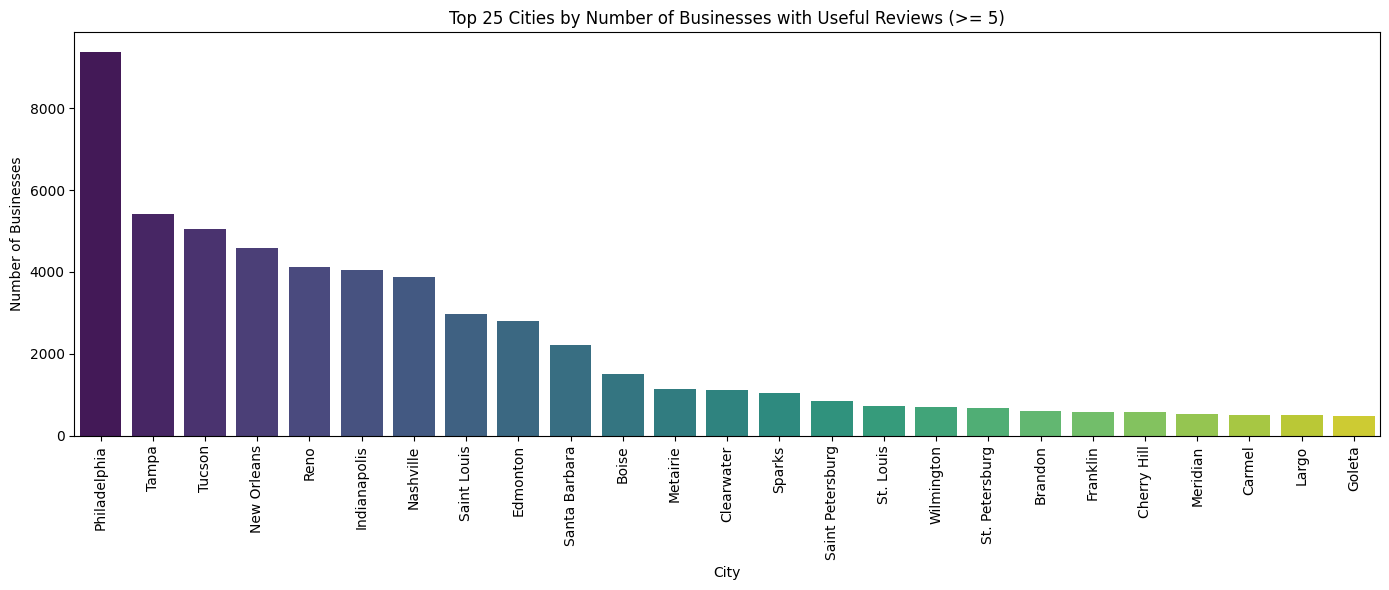

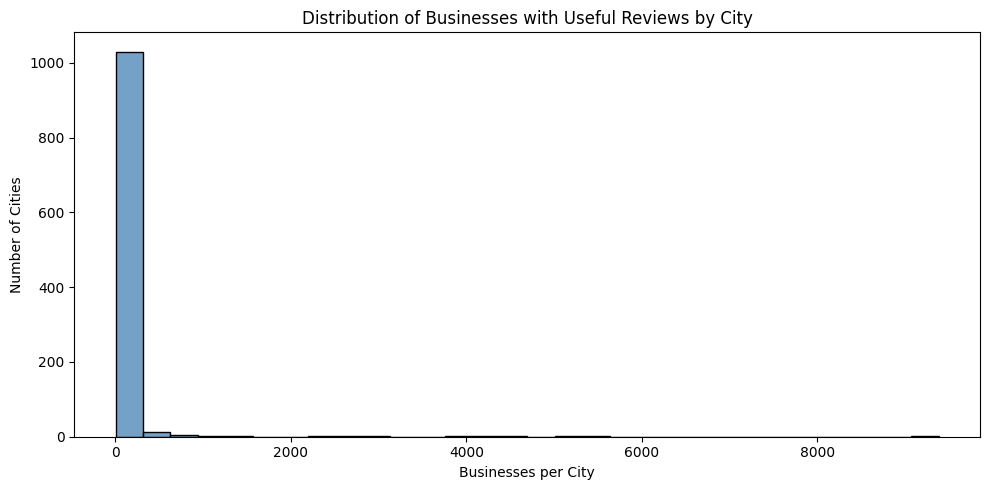

Average number of businesses per city: 78.90
Standard deviation of businesses per city: 477.18


In [12]:
# Plot business counts for the selected cities and the distribution of business counts per city
import matplotlib.pyplot as plt
import seaborn as sns

city_counts = business_present['city'].value_counts()

# Bar plot for top cities
plt.figure(figsize=(14, 6))
sns.barplot(x=city_counts.index[:25], y=city_counts.values[:25], palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 25 Cities by Number of Businesses with Useful Reviews (>= 5)')
plt.xlabel('City')
plt.ylabel('Number of Businesses')
plt.tight_layout()
plt.show()

# Distribution of business counts across cities
plt.figure(figsize=(10, 5))
sns.histplot(city_counts, bins=30, color='steelblue')
plt.title('Distribution of Businesses with Useful Reviews by City')
plt.xlabel('Businesses per City')
plt.ylabel('Number of Cities')
plt.tight_layout()
plt.show()

# Average and deviation of business counts per city
avg_businesses_per_city = city_counts.mean()
std_businesses_per_city = city_counts.std()
print(f"Average number of businesses per city: {avg_businesses_per_city:.2f}")
print(f"Standard deviation of businesses per city: {std_businesses_per_city:.2f}")

In [13]:
cat = business_present['categories'].str.split(',')
cat

2         [Department Stores,  Shopping,  Fashion,  Home...
3         [Restaurants,  Food,  Bubble Tea,  Coffee & Te...
6         [Sporting Goods,  Fashion,  Shoe Stores,  Shop...
7                    [Synagogues,  Religious Organizations]
10                 [Department Stores,  Shopping,  Fashion]
                                ...                        
150334    [Health & Medical,  Yoga,  Shopping,  Naturopa...
150335                       [Hospitals,  Health & Medical]
150339    [Restaurants,  Comfort Food,  Food,  Food Truc...
150341                        [Nail Salons,  Beauty & Spas]
150344    [Fitness/Exercise Equipment,  Eyewear & Optici...
Name: categories, Length: 83635, dtype: object

In [14]:
category_counts = cat.dropna().explode().str.strip().value_counts()
popular_categories = set(category_counts[category_counts >= 1000].index)

def keep_popular(categories):
    if not categories:
        return []
    return [c.strip() for c in categories if c.strip() in popular_categories]

cat = cat.dropna().apply(keep_popular)
cat = cat[cat.map(bool)]

print(f"Kept {len(cat)} businesses with at least one popular category")
print(f"Popular categories retained: {len(popular_categories)}")

Kept 82792 businesses with at least one popular category
Popular categories retained: 78


78


C:\Users\gfnmj\AppData\Local\Temp\ipykernel_12008\463293137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


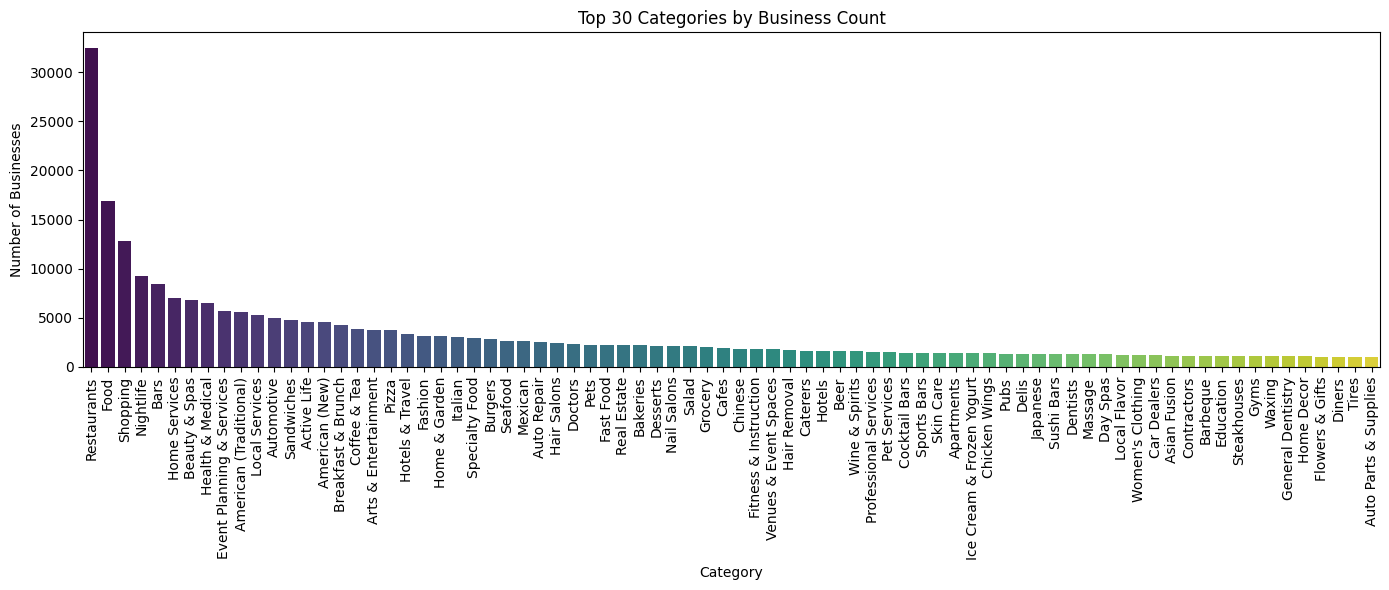

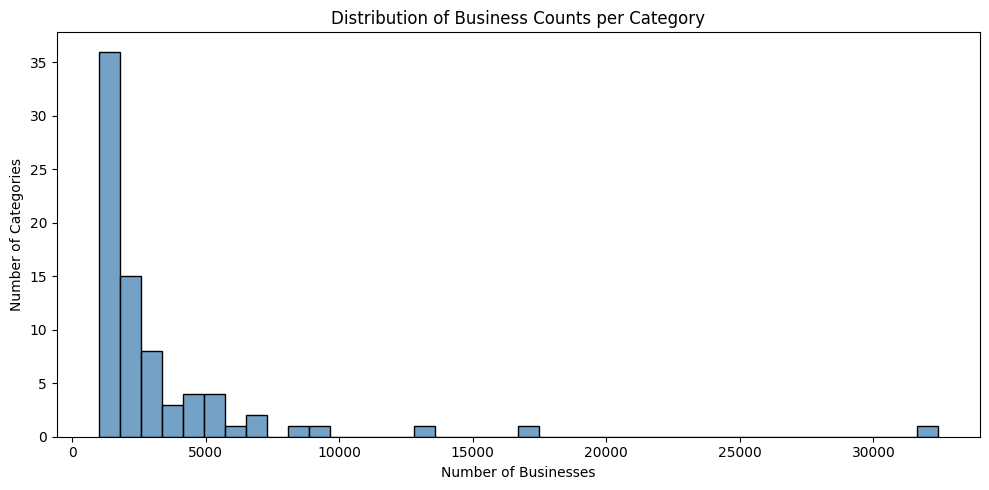

In [15]:
category_counts = cat.dropna().explode().str.strip().value_counts()
print(len(category_counts))
plt.figure(figsize=(14, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 30 Categories by Business Count')
plt.xlabel('Category')
plt.ylabel('Number of Businesses')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(category_counts, bins=40, color='steelblue')
plt.title('Distribution of Business Counts per Category')
plt.xlabel('Number of Businesses')
plt.ylabel('Number of Categories')
plt.tight_layout()
plt.show()

C:\Users\gfnmj\AppData\Local\Temp\ipykernel_12008\3060165523.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_ratios_reviews.index, y=null_ratios_reviews.values, palette='viridis')
C:\Users\gfnmj\AppData\Local\Temp\ipykernel_12008\3060165523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_ratios_business.index, y=null_ratios_business.values, palette='viridis')


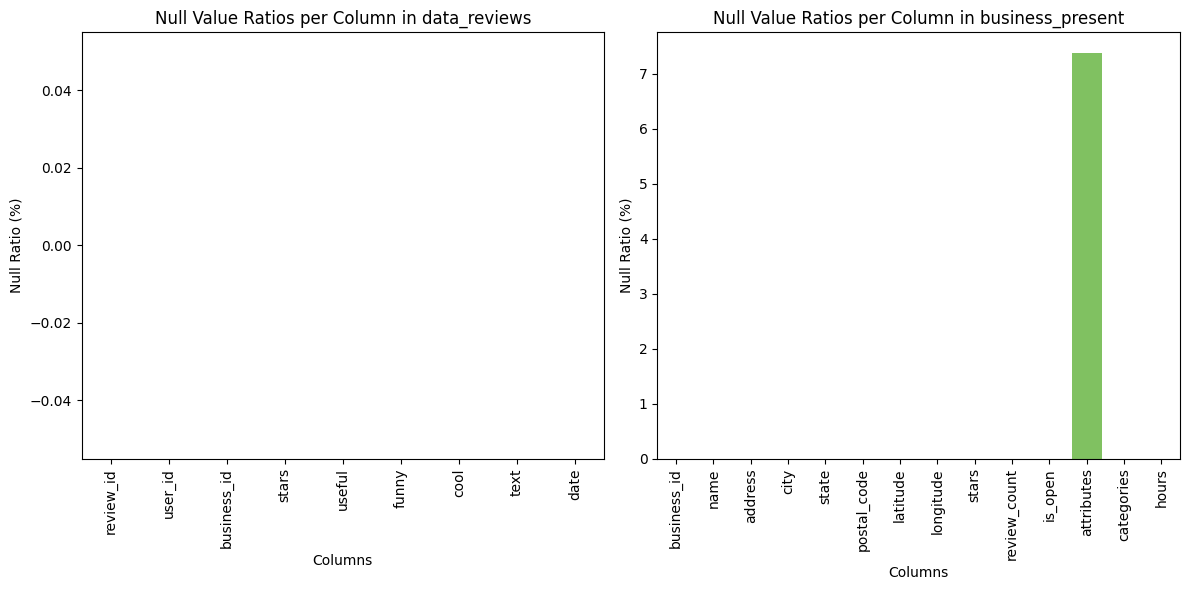

In [20]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate null value ratios for data_reviews
null_ratios_reviews = data_reviews.isnull().mean() * 100

# Calculate null value ratios for business_present
null_ratios_business = business_present.isnull().mean() * 100

# Plot for data_reviews
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=null_ratios_reviews.index, y=null_ratios_reviews.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Null Value Ratios per Column in data_reviews')
plt.ylabel('Null Ratio (%)')
plt.xlabel('Columns')

# Plot for business_present
plt.subplot(1, 2, 2)
sns.barplot(x=null_ratios_business.index, y=null_ratios_business.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Null Value Ratios per Column in business_present')
plt.ylabel('Null Ratio (%)')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()

In [17]:
# Fill null hours with default business hours (8-20 for weekdays, excluding Saturday and Sunday)
default_hours = {
    'Monday': '8:0-20:0',
    'Tuesday': '8:0-20:0',
    'Wednesday': '8:0-20:0',
    'Thursday': '8:0-20:0',
    'Friday': '8:0-20:0'
}

business_present['hours'] = business_present['hours'].apply(
    lambda x: default_hours if x is None or (isinstance(x, float) and pd.isna(x)) else x
)

C:\Users\gfnmj\AppData\Local\Temp\ipykernel_12008\2519863666.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_present['hours'] = business_present['hours'].apply(


In [19]:
business_present = business_present.dropna(subset=['categories'])

In [22]:
business_present.head(1)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


In [ ]:
business_present = business_present.drop(columns=['attributes', 'address', 'state', 'city', 'postal_code', 'latitude', 'longitude', 'is_open', 'review_count'])

In [27]:
business_present.head(1)

,business_id,name,stars,categories,hours
2,tUFrWirKiKi_TAnsVWINQQ,Target,3.5,"Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


In [30]:
business_present.shape


(83594, 5)

In [31]:
business_present = business_present[business_present.index.isin(cat.index)]

One hot in categories ?
Hours = hours in week?
Reviews created weighted embdeings between reviews for conrecte buisness?

Whole data is embeding of all this fiels except id?


train to predict buisness from embed reviews and average star
give model solve vice verse task